# Goals
The goal of this report is to explore the dataset and try to find out whether there is a correlation between proximity of petrol stations and their earnings. We will try to use the correlation and create a model which predicts earnings of a petrol station built in a proximity of other petrol stations. We also try to find out what proximity matters the most.

In [ ]:
# Drop useless columns
dataSet = pd.read_csv("data/benz-tr.csv")
czechiaOnlyDataSet = dataSet[dataSet.country == "cze"]
czechiaOnlyDataSet = czechiaOnlyDataSet.drop(columns=["clst", "clid", "day", "hour", "fav", "fav_main", "cl_gps_lat", "cl_gps_lon", "name", "dist", "country"])

stationsDataSet = czechiaOnlyDataSet.groupby("posid", as_index=False).agg(
    total_amt=("amt", "sum"),
    gps_lat=("pos_gps_lat", lambda x: x.mode()[0] if not x.mode().empty else np.nan),
    gps_lon=("pos_gps_lon", lambda x: x.mode()[0] if not x.mode().empty else np.nan),
    city=('city', 'first')
)
#print("There are", (stationsDataSet.shape)[0], "unique posid values, but there might be some duplicates.")
#print("Since we also have gps coordinates of the stations and their precision is up to 5 or 6 decimal places, which is precise up to 0.1 meters, we will consider stations sharing same gps to be duplicate.")

duplicateSubset = ["gps_lat", "gps_lon"]

#print('\nCount of duplicated gps locations is',
  #    sum(stationsDataSet.duplicated(subset=duplicateSubset)))

stationsWithDifferingGPS = stationsDataSet.groupby(['gps_lat', 'gps_lon'], as_index=False).agg(
    total_amt=('total_amt', 'sum'),
    posid=('posid', 'first'),
    city=('city', 'first')
)

# print("Our final count of stations is", (stationsWithDifferingGPS.shape)[0])

In [ ]:
# Drop useless columns
dataSet = pd.read_csv("data/benz-tr.csv")
czechiaOnlyDataSet = dataSet[dataSet.country == "cze"]
czechiaOnlyDataSet = czechiaOnlyDataSet.drop(columns=["clst", "clid", "day", "hour", "fav", "fav_main", "cl_gps_lat", "cl_gps_lon", "name", "dist", "country"])

stationsDataSet = czechiaOnlyDataSet.groupby("posid", as_index=False).agg(
    total_amt=("amt", "sum"),
    gps_lat=("pos_gps_lat", lambda x: x.mode()[0] if not x.mode().empty else np.nan),
    gps_lon=("pos_gps_lon", lambda x: x.mode()[0] if not x.mode().empty else np.nan),
    city=('city', 'first')
)
#print("There are", (stationsDataSet.shape)[0], "unique posid values, but there might be some duplicates.")
#print("Since we also have gps coordinates of the stations and their precision is up to 5 or 6 decimal places, which is precise up to 0.1 meters, we will consider stations sharing same gps to be duplicate.")

duplicateSubset = ["gps_lat", "gps_lon"]

#print('\nCount of duplicated gps locations is',
  #    sum(stationsDataSet.duplicated(subset=duplicateSubset)))

stationsWithDifferingGPS = stationsDataSet.groupby(['gps_lat', 'gps_lon'], as_index=False).agg(
    total_amt=('total_amt', 'sum'),
    posid=('posid', 'first'),
    city=('city', 'first')
)

# print("Our final count of stations is", (stationsWithDifferingGPS.shape)[0])

## Data desctiption and overview

The dataset contains various data about transactions. It contains information about clients and petroil stations, including their gps locations. It contains many numerical columns, such as amount spent at per transaction and the respective time of the transaction. It also contains data about the country and city of the transaction.

### Dataset Columns

* clid: client id
* posid: id of the payment place (petrol station)
* day: payment date in the Y-m-d format
* hour: payment hour (0-23)
* amt: payment amount in CZK
* fav: is this station flagged to be one of favourite stations of that client?
* fav_main: is this station flagged to be the most favourite station of that client?
* cl_gps_lat, cl_gps_lon: GPS coordinates of the client's living place (possibly the municipality only, not street or house exactly)
* country: payment country
* city: payment city
* name: payment place (station) name
* clst: number of cluster where the station fits by clients behaviour (0 = unclustered)
* pos_gps_lat, pos_gps_lon: GPS coordinates of the payment place (for the stations in the Czech republic only)
* dist: distance in km between client living place and payment place

In [2]:
import pandas as pd
import numpy as np
from scipy import stats

from pandas.api.types import CategoricalDtype

dataSet: pd.DataFrame = pd.read_csv("data/benz-tr.csv")

#I dont know what the cluster is so i will drop it
dataSet = dataSet.drop(columns=["clst"])

dataSet.sample(10)

,clid,posid,day,hour,amt,fav,fav_main,cl_gps_lat,cl_gps_lon,country,city,name,pos_gps_lat,pos_gps_lon,dist
1595331,19246744,8382,2017-09-16,11.0,582.00,1,1,49.770649,17.118139,cze,unicov,benzina cs 0618,49.764832,17.113749,0.719669
1844816,14545251,37820,2017-09-04,12.0,300.00,1,1,50.108022,14.503183,cze,praha 9,csphm prazske sluzby,50.098175,14.502474,1.096071
136546,19870565,4600,2017-11-23,22.0,42.80,1,1,49.213060,16.576647,cze,brno lisen,mol brno 608,49.201800,16.666920,6.676435
388229,10348957,5301,2017-05-08,14.0,114.00,0,0,49.774952,18.452427,cze,havirov,shell 8039,49.788540,18.406628,3.618838
533011,14773836,5677,2017-05-06,11.0,300.10,1,1,49.312768,15.395498,cze,jihlava,benzina cs 0505,49.381119,15.592179,16.148157
760327,15140174,6409,2017-04-09,10.0,300.77,1,1,50.515176,14.050395,cze,lovosice,pap oil lovosice 348,50.515176,14.050395,0.000000
1229635,10132218,7418,2017-04-26,9.0,170.00,0,0,50.108022,14.503183,cze,praha 9,benzina cs 0229,50.069463,14.457072,5.404129
572298,19371289,5776,2018-01-04,16.0,300.18,1,0,50.234734,12.885935,cze,karlovy vary,mol karlovy vary 64,50.213260,12.875480,2.500928
1056457,18039092,7087,2017-11-09,19.0,126.00,1,1,50.246159,14.152865,cze,panensky tynec,benzina cs 0271,50.295586,13.910060,18.110482
1841362,20107309,37775,2017-10-16,18.0,900.00,0,0,50.061091,14.289606,cze,podebrady,benzina cs 0279,50.133808,15.098991,58.296340


The dataset can be considered large. Looking at the basic statistics,
It contains 1853551 transactions.
121834 clients.
Transactions span accross 102 countries.

In [24]:
# dataSet.shape[0]
# dataSet["clid"].nunique()
# dataSet["country"].nunique()

If we look at the transactions from the perspective of countries, the vast majority is located in Czech Republic. Countries are notated by an acronym. The number of transactions in the second most recorded country in our dataset is Slovakia. But even that is negligible compared to Czech Republic.

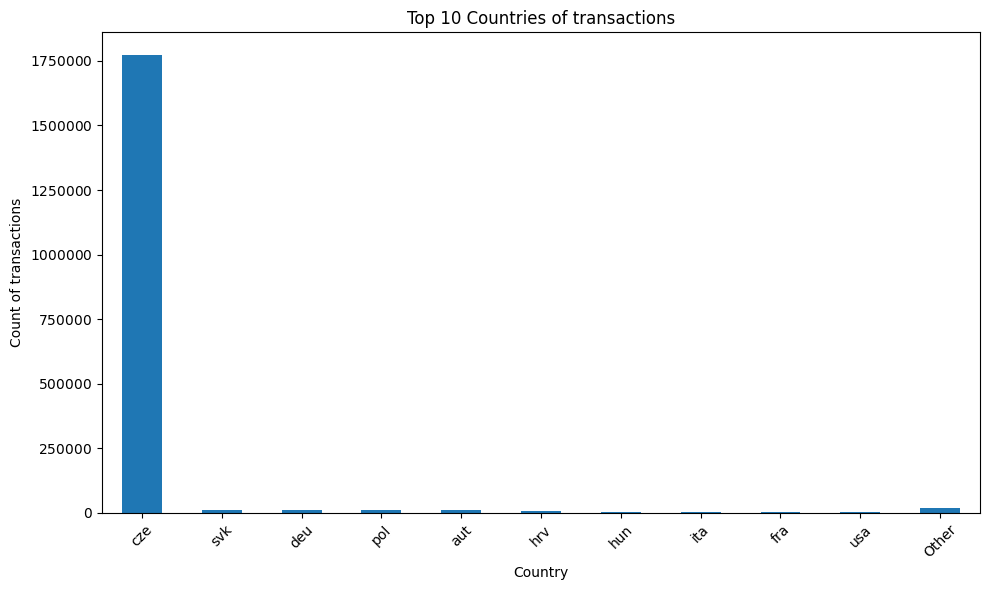

In [4]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter


country_counts = dataSet['country'].value_counts()

top_10_countries = country_counts.head(10)

other_countries_sum = country_counts[10:].sum()

combined_counts = pd.concat([top_10_countries, pd.Series({'Other': other_countries_sum})])

plt.figure(figsize=(10, 6))
ax = combined_counts.plot(kind='bar')
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='plain', axis='y')
plt.xlabel('Country')
plt.ylabel('Count of transactions')
plt.title('Top 10 Countries of transactions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Despite the lack of the number of individual transactions we can look at a basic statistics for the 10 most recorded countries in terms of spending. Spending is the metric which will interest us the most. The following table shows number of transactions per country and mean, median, the standard deviation, max and min value of the transaction.

In [5]:
spendingByCountryByCountOfTransactions = (dataSet.groupby("country").agg({"amt": ["count", "mean", "median", "std", "max", "min"]})).sort_values(by=("amt", "count"), ascending=False).head(10)
spendingByCountryByCountOfTransactions

amt                                                   
           count         mean   median         std       max    min
country                                                            
cze      1771893   546.697695  400.000  510.345260  38990.00  10.00
svk        12891   436.780463  264.250  494.533912   6964.82  11.05
deu        11634   686.583850  392.950  776.085528  30456.36  10.40
pol         9869   537.039078  348.070  513.150423   3657.90  10.10
aut         9826   736.005056  587.520  607.090381  17452.05  12.23
hrv         5941   864.065341  821.960  790.328453  22857.44  10.67
hun         3657   513.889521  263.160  535.816376   4158.78  10.37
ita         2814  1084.157150  999.760  692.003271   9344.16  10.67
fra         2432   834.240551  702.455  682.103188   5321.55  10.93
usa         1958   467.642589  434.030  342.091820   2524.28  10.89

Because of the lack of data in other countries it would not be wise to make a world wide assumptions based on this dataset only. We could use the data to reason about the czech citizens shopping at petrol stations and compare them excluding czechia, but that would not make much sense from the business perspective, as foreign petrol companies would not focus on such a small customer base. From a scientific perspective, the dataset is too small. That is why we filter out the foreign data and focus on Czech republic only. Let us make a similar spending statistics per czech cities.

In [6]:
czechiaOnlyDataSet = dataSet[dataSet.country == "cze"]
spendingByCityByCountOfTransactions = (czechiaOnlyDataSet.groupby("city").agg({"amt": ["count", "mean", "median", "std", "max", "min"]})).sort_values(by=("amt", "count"), ascending=False).head(10)
spendingByCityByCountOfTransactions

amt                                               
                count        mean  median         std      max   min
city                                                                
brno            64585  636.823732  499.80  542.689146  15771.0  10.0
ostrava         57683  542.820984  404.01  463.236869   5000.0  10.0
praha 9         37416  637.865046  499.90  535.155676  10000.0  10.0
plzen           36467  678.512126  500.30  552.533587  11532.0  10.0
praha           29605  574.895196  375.50  569.332641  22800.0  10.0
liberec         25564  547.460490  400.40  508.412329  17733.0  10.0
praha 5         25378  679.775567  500.20  529.841868   5000.0  12.0
praha 10        24950  581.791514  400.10  752.406389  21013.0  10.0
hradec kralove  22782  557.349313  400.16  537.809290  14253.0  10.0
usti nad labem  22214  526.305433  390.65  496.569864   7680.0  10.0

We can see that Prague is devided into its city districts. Let us aggregate all the districts of Prague into Prague.

C:\Users\asus\AppData\Local\Temp\ipykernel_20076\3808721431.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  czechiaOnlyDataSet["city"] = czechiaOnlyDataSet["city"].apply(lambda x: change_prague_districts_to_prague(x))


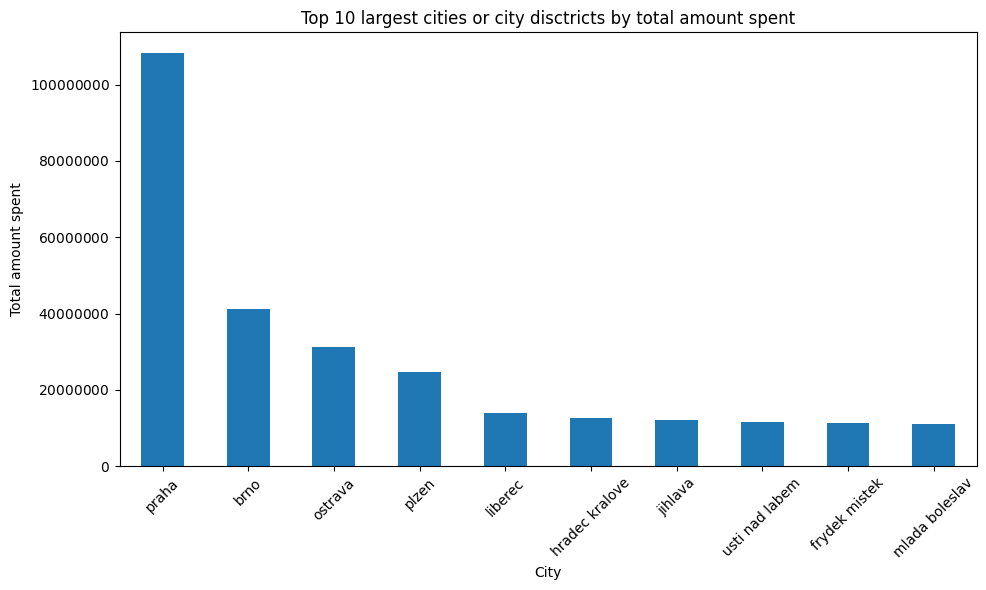

In [7]:
def change_prague_districts_to_prague(city):
    if city.startswith("praha"):
        return "praha"
    return city

czechiaOnlyDataSet["city"] = czechiaOnlyDataSet["city"].apply(lambda x: change_prague_districts_to_prague(x))

top_10_spending_cities = (czechiaOnlyDataSet.groupby("city").agg({"amt": "sum"}))["amt"]
top_10_spending_cities = top_10_spending_cities.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
ax = top_10_spending_cities.plot(kind='bar')
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='plain', axis='y')
plt.xlabel('City')
plt.ylabel('Total amount spent')
plt.title('Top 10 largest cities or city disctricts by total amount spent')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The recorded transaction from our dataset sum up to 968,689,819 czech crowns spend in czechia.

In [29]:
# print("The recorded transaction from our dataset sum up to" ,format(int(czechiaOnlyDataSet["amt"].sum()), ","), "czech crowns spend in czechia.")

## Missing and duplicated data

Some columns are missing values, but overall the vast majority of the data is complete. As has been hinted above, the most interesting column for us is the amount, which contains no null or missing data. Another importand value is the city, which no record in czechia misses.

##### Counts of missing values by column

In [21]:
missingCounts = pd.DataFrame(len(dataSet) - dataSet.count())
missingCounts.columns = [''] * len(missingCounts.columns)
missingCounts

,
clid,0
posid,0
day,0
hour,2631
amt,0
fav,0
fav_main,0
cl_gps_lat,14413
cl_gps_lon,14413
country,10


To find duplicates we can logically assume that each transaction which has the same amount spent, the time of the day and client id to be duplicate.

In [30]:
# duplicateSubset = ["amt", "day", "hour", "clid"]
# print('Count of duplicated rows:', sum(czechiaOnlyDataSet.duplicated(subset=duplicateSubset)))

Count of duplicated rows was 769

## Featurization

I wanted to explore something that is not visible immediately and might be useful from the business point of view. Let us say we are working for a company which has petrol stations and in an imaginary time of good economy we would like to expand our business. The company would like to explore where in Czechia we could build a new station. One of the variables which we must take into consideration is the market saturation. If we could tell whether the distances between petrol stations mattered, the company could then start finding a place for their new station. Since we have ids of the stations, we can aggregate the data into data per station.

In [31]:
# Drop useless columns
dataSet = pd.read_csv("data/benz-tr.csv")
czechiaOnlyDataSet = dataSet[dataSet.country == "cze"]
czechiaOnlyDataSet = czechiaOnlyDataSet.drop(columns=["clst", "clid", "day", "hour", "fav", "fav_main", "cl_gps_lat", "cl_gps_lon", "name", "dist", "country"])

stationsDataSet = czechiaOnlyDataSet.groupby("posid", as_index=False).agg(
    total_amt=("amt", "sum"),
    gps_lat=("pos_gps_lat", lambda x: x.mode()[0] if not x.mode().empty else np.nan),
    gps_lon=("pos_gps_lon", lambda x: x.mode()[0] if not x.mode().empty else np.nan),
    city=('city', 'first')
)
#print("There are", (stationsDataSet.shape)[0], "unique posid values, but there might be some duplicates.")
#print("Since we also have gps coordinates of the stations and their precision is up to 5 or 6 decimal places, which is precise up to 0.1 meters, we will consider stations sharing same gps to be duplicate.")

duplicateSubset = ["gps_lat", "gps_lon"]

#print('\nCount of duplicated gps locations is',
  #    sum(stationsDataSet.duplicated(subset=duplicateSubset)))

stationsWithDifferingGPS = stationsDataSet.groupby(['gps_lat', 'gps_lon'], as_index=False).agg(
    total_amt=('total_amt', 'sum'),
    posid=('posid', 'first'),
    city=('city', 'first')
)

# print("Our final count of stations is", (stationsWithDifferingGPS.shape)[0])

There are 3000 unique posid values, but there might be some duplicates.
Since we also have gps coordinates of the stations and their precision is up to 5 or 6 decimal places, which is precise up to 0.1 meters, we will consider stations sharing same gps to be duplicate.

Count of duplicated gps locations is 851
Our final count of stations is 2148

Using the gps location we can visualise the stations at the map of Czech Republic. Each circle represents the station. The size and the color of the station represent the total amount of earnings at that station.

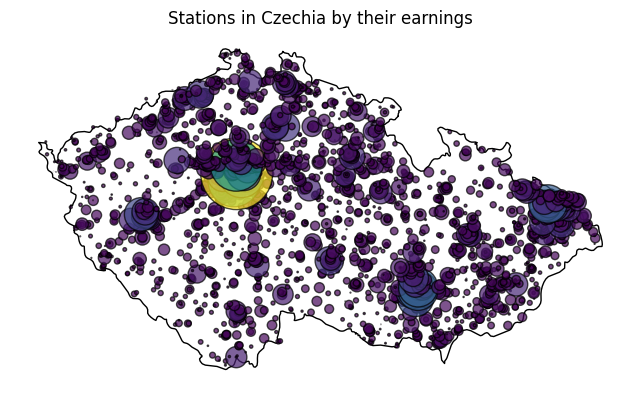

In [197]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point

# Load the downloaded shapefile (adjust the path)
world = gpd.read_file('./maps/ne_10m_admin_0_countries.shp')

# Filter for Czechia
czech_map = world[world['NAME'] == 'Czechia']

geometry = [Point(xy) for xy in zip(stationsWithDifferingGPS['gps_lon'], stationsWithDifferingGPS['gps_lat'])]

gdf_points = gpd.GeoDataFrame(stationsWithDifferingGPS, geometry=geometry, crs="EPSG:4326")

marker_sizes = gdf_points['total_amt'] * 0.0001  # Scale factor to adjust the size

fig, ax = plt.subplots(figsize=(8, 8))
czech_map.plot(ax=ax, color='white', edgecolor='black')

gdf_points.plot(
    ax=ax,
    column='total_amt',
    cmap='viridis',
    markersize=marker_sizes,
    alpha=0.7, # Transparency for better visibility
    edgecolor='black'
)

plt.title('Stations in Czechia by their earnings')
ax.axis('off')
plt.show()

From the map it seems like the hypothesis is not correct, because the biggest circles representing the largest earnings are clustered together. We can easily reason that it is because the highest earnings are in the largest cities with the largest population density, incomes and other variables and therefore possible earnings. But we will not give up just yet. Mixing cities and gas stations is like comparing pears to apples.We must reason about them separately. We could only look at the petrol stations outside cities. But since our dataset contains city in each transaction, either all of them are in a city or town, or each station is considered to fall under the nearest city. It would be difficult to find out whether each station actually is in the city or not. Therefore we will only consider the stations in cities. And since the cities vary in sizes, incomes and density, we will use data of the largest cities only and stations in close proximity to them.

In [34]:
from geopy.distance import geodesic

major_cities_coords = {
    'brno': (49.195061, 16.606836),
    'ostrava': (49.820923, 18.262524),
    'liberec': (50.766280, 15.054339),
    'liberec': (50.766280, 15.054339),
    'plzen': (49.738430, 13.373637),
    'olomouc': (49.593777, 17.250879),
    'budejovice': (48.975658, 14.480255),
    'hradec kralove': (50.210361, 15.825211)
}


radius = 1

def is_near_major_city(lat, lon, rowCity, cities_coords, radius_km):
    for city, coords in cities_coords.items():
        if city.startswith(rowCity):
            return True
        if geodesic((lat, lon), coords).km <= radius_km:
            return True
    return False

stationsWithDifferingGPS['near_major_city'] = stationsWithDifferingGPS.apply(
    lambda row: is_near_major_city(row['gps_lat'], row['gps_lon'], row['city'], major_cities_coords, radius),
    axis=1
)

stationsWithDifferingGPS = stationsWithDifferingGPS[stationsWithDifferingGPS['near_major_city']]

stationsWithDifferingGPS = stationsWithDifferingGPS.drop(columns='near_major_city')
# print("That leaves us with", (stationsWithDifferingGPS.shape)[0], "stations.")

That leaves us with 104 stations.

Visualising at the map would not tell us much, because we can not see the cities in detail. We can visualise this using Kamada Kawai graph, which is a negative force-directed graph, where edges represent the distances between nodes. We can compute the distances between each station using our geo coordinates. The following visualisation using Kamada Kawai graph represents stations as circles and the size represents the respective earnings of that station. As we do not know yet what distance matters in terms of proximity and earnings, for each station we will consider only the stations in a specified radius.

In [199]:
from geopy import distance

# Calculate geo distance between each station
stationPairs = stationsWithDifferingGPS.merge(stationsWithDifferingGPS, how='cross', suffixes=('_1', '_2'))

# Remove self-pairings and duplicate pairs
stationPairs = stationPairs[stationPairs['posid_1'] < stationPairs['posid_2']]

# Reset the index for clarity
stationPairs.reset_index(drop=True, inplace=True)

stationPairs["distance"] = stationPairs.apply(
    lambda row: distance.distance(
        (row["gps_lat_1"], row["gps_lon_1"]), 
        (row["gps_lat_2"], row["gps_lon_2"])
    ).km, 
    axis=1
)

stationPairs = stationPairs.drop(columns=["gps_lat_1", "gps_lat_2", "gps_lon_1", "gps_lon_2", "total_amt_1", "total_amt_2"])

In [200]:
radii = [0.5, 1, 2, 4]
stationPairsLimitedPerRadius = []

for radius in radii:
    stationPairsLimitedPerRadius.append(stationPairs[stationPairs["distance"] <= radius])

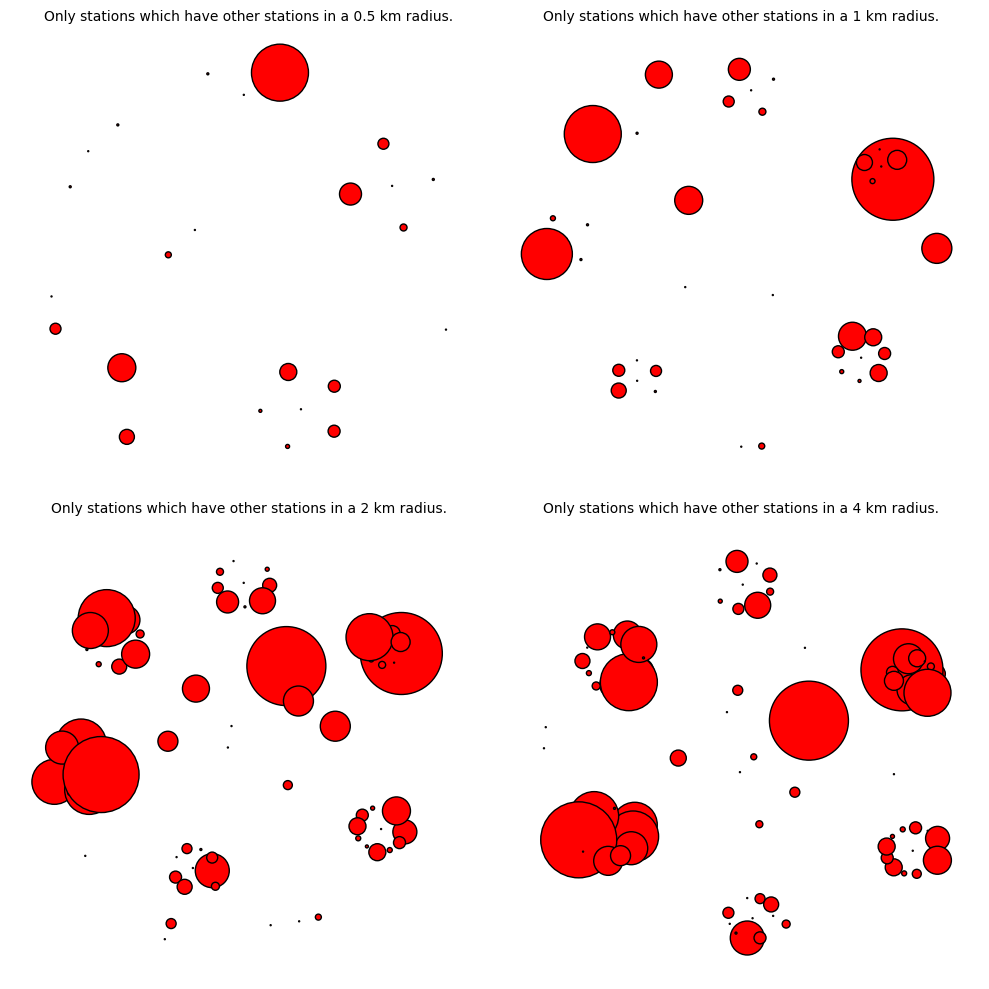

In [201]:
import igraph as ig
import matplotlib.pyplot as plt

num_graphs = len(stationPairsLimitedPerRadius)
cols = 2  # Two plots per row
rows = (num_graphs + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(10, 5 * rows))
axes = axes.flatten()

for i, (stationPairs, radius) in enumerate(zip(stationPairsLimitedPerRadius, radii)):
    g = ig.Graph.TupleList(stationPairs.itertuples(index=False), weights=True)

    node_sizes = dict(zip(stationsWithDifferingGPS["posid"], 
                          stationsWithDifferingGPS["total_amt"].apply(lambda x: x / 100000)))

    g.vs["size"] = [node_sizes.get(posid, 1) for posid in g.vs["name"]]

    layout = g.layout("kamada_kawai", weights=g.es["weight"])

    # Plot on the corresponding subplot axis
    ig.plot(
        g,
        layout=layout,
        target=axes[i],
        vertex_size=g.vs["size"],
        bbox=(0, 0, 400, 400),
        edge_width=0
    )

    # Set a title based on the radius
    axes[i].set_title(f"Only stations which have other stations in a {radius} km radius.", fontsize=10)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


We can reason about our original question differently and ask, whether there is a correlation between number of stations in a radius and eaernings of the station. And if there is, at what radius does it matter the most.

In [203]:
stationInRadiusPerRadius = []

for stationsPairsLimited in stationPairsLimitedPerRadius:
    # Melt the DataFrame to unify posid_1 and posid_2
    stationDistances = pd.melt(
        stationsPairsLimited,
        id_vars=['distance'],
        value_vars=['posid_1', 'posid_2'],
        var_name='pos_type',
        value_name='posid'
    )

    stationDistances = stationDistances.drop('pos_type', axis=1)

    stationsInRadius = stationDistances.groupby("posid").agg(
        stations_in_radius=("distance", "count"),
        posid=("posid", "first")
    )

    stationsInRadius = stationsInRadius.set_index("posid").join(stationsWithDifferingGPS.set_index("posid"))

    stationsInRadius = stationsInRadius.reindex(stationsWithDifferingGPS["posid"]).fillna(0)

    stationsInRadius = stationsInRadius.drop(columns=["gps_lat", "gps_lon"], errors='ignore')

    stationInRadiusPerRadius.append(stationsInRadius)

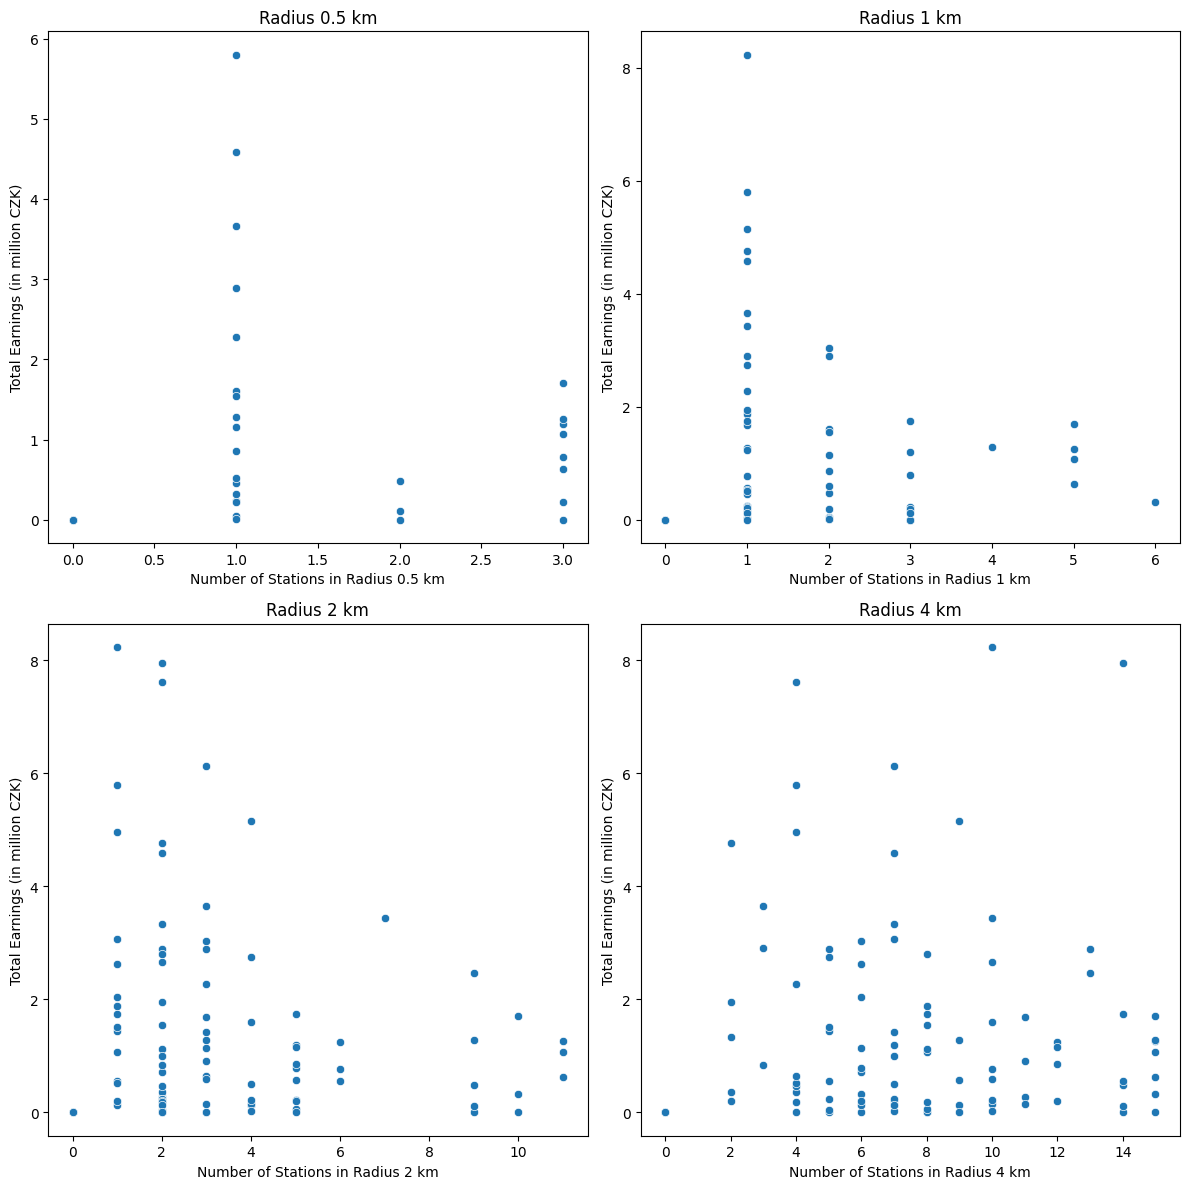

In [204]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# Set display precision and disable scientific notation globally for pandas
pd.set_option("display.precision", 2)
pd.set_option('display.float_format', '{:.0f}'.format)

def divide(x):
    return x / 1000000

# Determine grid size for subplots
num_graphs = len(stationInRadiusPerRadius)
cols = 2  # Two plots per row
rows = (num_graphs + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(12, 6 * rows))
axes = axes.flatten()

# Iterate over each stationsInRadius DataFrame and plot in separate subplots
for i, (stationsInRadius, radius) in enumerate(zip(stationInRadiusPerRadius, radii)):
    stationsInRadius["total_amt"] = stationsInRadius["total_amt"].apply(lambda x: divide(x))
    
    sns.scatterplot(
        data=stationsInRadius,
        x="stations_in_radius",
        y="total_amt",
        ax=axes[i]
    )
    
    # Set axis labels and title for each subplot
    axes[i].set_xlabel(f"Number of Stations in Radius {radius} km")
    axes[i].set_ylabel("Total Earnings (in million CZK)")
    axes[i].set_title(f"Radius {radius} km")
    
    # Format axes to display integers and avoid scientific notation
    axes[i].xaxis.set_major_formatter(ScalarFormatter())
    axes[i].yaxis.set_major_formatter(ScalarFormatter())
    axes[i].ticklabel_format(style='plain', axis='both')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()



It appears that our hypothesis holds for number of stations in 0.5, 1 and 2 kilometer radius, except for 0 outliers, meaning that if there is no petrol station in the corresponding radius, than the station is not in a desirable location. We will not consider those stations, because there are likely other factors, such as being in an undesirable part of a city. Trend appears to be opposite for larger radii, likely meaning that if there is not enough stations in higher radius then the location is not desirable.

## Modeling
We have already prepared the model from the data. We have number of stations in a radius for multiple radii. For that radii, we will try to predict the earnings of a station which would be built in a location with a number of stations in proximity. I would first like to repeat, how we got to the point where we have number of stations per radius from the original dataset which contained information about individual transactions per client per station, having gps coordinates for each station.

### Data preparation
First we filtered out transactions not in Czech Republic and removed duplicated transactions.
Then we aggregated the data into petrol stations and their respective earnings, filtering out duplicated stations.
We filter out the stations not in proximity of a major Czech city.
We used geo coordinates to compute distances between the stations.
We define some radii, which we will consider, filtering out stations pair distances which are too large, such as between different cities, or stations at a different part of a city, for each radius considering only the pair stations in that radius.
Then we computed the number of stations in the radius per each station.

In [17]:
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import cross_val_score
import statsmodels.api as sm
import statsmodels.formula.api as smf

dataSet = pd.read_csv("data/benz-tr.csv")
czechiaOnlyDataSet = dataSet[dataSet.country == "cze"]
czechiaOnlyDataSet = czechiaOnlyDataSet.drop(columns=["clst", "clid", "day", "hour", "fav", "fav_main", "cl_gps_lat", "cl_gps_lon", "name", "dist", "country"])

stationsDataSet = czechiaOnlyDataSet.groupby("posid", as_index=False).agg(
    total_amt=("amt", "sum"),
    gps_lat=("pos_gps_lat", lambda x: x.mode()[0] if not x.mode().empty else np.nan),
    gps_lon=("pos_gps_lon", lambda x: x.mode()[0] if not x.mode().empty else np.nan),
    city=('city', 'first')
)
duplicateSubset = ["gps_lat", "gps_lon"]

stationsWithDifferingGPS = stationsDataSet.groupby(['gps_lat', 'gps_lon'], as_index=False).agg(
    total_amt=('total_amt', 'sum'),
    posid=('posid', 'first'),
    city=('city', 'first')
)

from geopy.distance import geodesic

major_cities_coords = {
    'praha': (50.073658, 14.418540),
    'brno': (49.195061, 16.606836),
    'ostrava': (49.820923, 18.262524),
    'liberec': (50.766280, 15.054339),
    'plzen': (49.738430, 13.373637),
    'olomouc': (49.593777, 17.250879),
    'budejovice': (48.975658, 14.480255),
    'hradec kralove': (50.210361, 15.825211)
}
radius = 1

def is_near_major_city(lat, lon, rowCity, cities_coords, radius_km):
    for city, coords in cities_coords.items():
        if city.startswith(rowCity):
            return True
        if geodesic((lat, lon), coords).km <= radius_km:
            return True
    return False

stationsWithDifferingGPS['near_major_city'] = stationsWithDifferingGPS.apply(
    lambda row: is_near_major_city(row['gps_lat'], row['gps_lon'], row['city'], major_cities_coords, radius),
    axis=1
)

stationsWithDifferingGPS = stationsWithDifferingGPS[stationsWithDifferingGPS['near_major_city']]
stationsWithDifferingGPS = stationsWithDifferingGPS.drop(columns='near_major_city')
from geopy import distance

# Calculate geo distance between each station
stationPairs = stationsWithDifferingGPS.merge(stationsWithDifferingGPS, how='cross', suffixes=('_1', '_2'))

# Remove self-pairings and duplicate pairs
stationPairs = stationPairs[stationPairs['posid_1'] < stationPairs['posid_2']]

# Reset the index for clarity
stationPairs.reset_index(drop=True, inplace=True)

stationPairs["distance"] = stationPairs.apply(
    lambda row: distance.distance(
        (row["gps_lat_1"], row["gps_lon_1"]), 
        (row["gps_lat_2"], row["gps_lon_2"])
    ).km, 
    axis=1
)

stationPairs = stationPairs.drop(columns=["gps_lat_1", "gps_lat_2", "gps_lon_1", "gps_lon_2", "total_amt_1", "total_amt_2"])

In [18]:
radii = [0.5, 1, 2, 4, 6, 10, 20]

stationPairsLimitedPerRadius = []

for radius in radii:
    stationPairsLimitedPerRadius.append(stationPairs[stationPairs["distance"] <= radius])

stationInRadiusPerRadius = []
for stationsPairsLimited in stationPairsLimitedPerRadius:
    stationDistances = pd.melt(stationsPairsLimited, id_vars=['distance'], value_vars=['posid_1', 'posid_2'], 
                  var_name='pos_type', value_name='posid')

    stationDistances = stationDistances.drop('pos_type', axis=1)

    stationsInRadius = stationDistances.groupby("posid").agg(
        stations_in_radius=("distance", "count"),
        posid=("posid", "first")
    )

    stationsInRadius = stationsInRadius.set_index("posid").join(stationsWithDifferingGPS.set_index("posid"))

    stationsInRadius = stationsInRadius.drop(columns=["gps_lat", "gps_lon"])
    stationInRadiusPerRadius.append(stationsInRadius)

Now we will try a linear regression as a base model for each radius. We use the number of stations in the specified radius to estimate the total earnings of a station. We try to predict intake for 2 stations in the particular radius.

In [20]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Initialize DataFrame with correct data types
results_df = pd.DataFrame(columns=[
    "Considered Radius (km)",
    "Intercept",
    "Beta Coefficient",
    "R²",
    "Cross-Validation R²",
    "MAE",
    "Predicted Intake"
])

for i, radius in enumerate(radii):
    X = stationInRadiusPerRadius[i][['stations_in_radius']]
    y = stationInRadiusPerRadius[i]['total_amt']

    # Fit Linear Regression model
    model = LinearRegression().fit(X, y)
    y_pred = model.predict(X)

    # Calculate metrics
    intercept = model.intercept_
    beta_coefficient = model.coef_[0]
    r_squared = model.score(X, y)
    mae = mean_absolute_error(y, y_pred)
    predicted_intake = model.predict(pd.DataFrame([[1]], columns=['stations_in_radius']))[0]

    # Cross-validation scores
    cross_val_r2 = cross_val_score(LinearRegression(), X, y, cv=4)

    # Safely append the results using loc
    results_df.loc[len(results_df)] = [
        radius,
        intercept,
        beta_coefficient,
        str(round(r_squared, 3)),
        list(map(lambda x : round(x, 3) ,cross_val_r2)),
        mae,
        predicted_intake
    ]

results_df


,Considered Radius (km),Intercept,Beta Coefficient,R²,Cross-Validation R²,MAE,Predicted Intake
0,0.5,1.854969e+06,-386666.244128,0.059,"[-0.217, -0.127, 0.114, 0.023]",1.010249e+06,1.468303e+06
1,1.0,1.974150e+06,-313829.617454,0.057,"[-0.2, -0.847, 0.042, 0.006]",1.220500e+06,1.660320e+06
2,2.0,2.702975e+06,-248839.066955,0.044,"[0.018, -1.272, -0.018, -0.849]",1.691453e+06,2.454136e+06
3,4.0,3.480425e+06,-207013.588748,0.06,"[-0.137, -0.558, 0.026, -0.376]",1.773399e+06,3.273412e+06
4,6.0,5.067033e+06,-275868.617005,0.11,"[-0.606, -0.197, 0.093, 0.15]",1.896550e+06,4.791165e+06
5,10.0,4.703116e+06,-185137.532458,0.062,"[-0.648, 0.058, -0.692, 0.138]",1.988897e+06,4.517979e+06
6,20.0,3.539824e+06,-98591.718495,0.026,"[-0.817, -3.433, 0.002, 0.064]",1.992046e+06,3.441232e+06


#### Results
The Beta Coefficients are all negative, meaning that our hypothesis is correct and that means, that more neaerby stations reduce earnings of a station. It shows that the Beta Coefficient is more important at smaller radii, meaning the number of stations in smaller radius decreases the earnings significantly. The degree of linear correlation (R squared) is low, meaning that while our hypothesis holds, the model using the number of stations is not enough to predict earnings. The highest degree of correlation appears to be in number of stations in 6 km radius and 10 km radius in cities.
The Mean Absolute Error(MAE) is in millions of czk, meaning that the model predictions are quite inaccurate.

## Summary
We have managed to created a model and explore the hypothesis that station proximity matters for earnings of the station.

We found out that the hypothesis is correct even though the causality is not very strong. Proximity is only one variable and if we really wanted to find out where to build a station or predict earnings of a station we would need to consider more variables in the model. What I think would be a better and similar way based on the geo location would be to not consider pure proximity, but rather driving distance to other stations. That however would be more difficult and expensive, because even though there are public free apis to compute driving distance between geo locations, their usage is limited and the number of requests would be too large. Doing so would make more sense in my opinion because in cities there can be many one way roads, or no direct roads between two close points, which make the proximity alone a less important variable. There are many other matrics such as differing population density, company owning the stations which might be close, but their business model might be much different shadowing proximity itself.

Another factor is that we can in no way know whether there were at the time of creating the dataset other stations.

On the other hand the hypothesis and the model is not completely useless and shows that the distance does matter to some extent.

I have not included other models or variables, because this model took comparatively a lot of effort to preprocess. We had to find additional data about czech cities and compute the distances between each considered station.